In [2]:
import pandas as pd
sales = pd.read_csv('../data/sales.csv')

In [3]:
## Top products by revenue
top_revenue_products = (
    sales.groupby(['StockCode','Description'])
    .agg(
        Revenue = ("Revenue", "sum"),
        Units =("Quantity", "sum")
    )
    .sort_values("Revenue",ascending=False)
    .head(10)
    .reset_index()
)
print("Top 10 Products by Revenue:")
print(top_revenue_products)

Top 10 Products by Revenue:
  StockCode                          Description    Revenue  Units
0         M                               Manual  262577.36   2765
1     22423             REGENCY CAKESTAND 3 TIER  169912.76  13691
2    85123A   WHITE HANGING HEART T-LIGHT HOLDER  158305.72  58387
3       DOT                       DOTCOM POSTAGE  116408.71    733
4     84879        ASSORTED COLOUR BIRD ORNAMENT   72890.19  45236
5     22086      PAPER CHAIN KIT 50'S CHRISTMAS    58127.30  17205
6    85099B              JUMBO BAG RED RETROSPOT   54368.82  30329
7     47566                        PARTY BUNTING   49664.12  10092
8      POST                              POSTAGE   49477.54   2310
9     84347  ROTATING SILVER ANGELS T-LIGHT HLDR   47954.49  23037


In [4]:
top_quantity_products = (
    sales.groupby(['StockCode','Description'])
    .agg(
        Units = ("Quantity","sum"),
        Revenue = ("Revenue",'sum')
    )
    .sort_values('Units',ascending=False)
    .head(10)
    .reset_index()
)
print("Top 10 Products by Quantity Sold:")
print(top_quantity_products)

Top 10 Products by Quantity Sold:
  StockCode                         Description  Units    Revenue
0    85123A  WHITE HANGING HEART T-LIGHT HOLDER  58387  158305.72
1     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS  55058   11383.97
2     17003                 BROCADE RING PURSE   48384    8922.80
3     21212    PACK OF 72 RETRO SPOT CAKE CASES  46728   24054.43
4     84879       ASSORTED COLOUR BIRD ORNAMENT  45236   72890.19
5     84991         60 TEATIME FAIRY CAKE CASES  36348   18151.40
6     21977  PACK OF 60 PINK PAISLEY CAKE CASES  31805   16187.31
7    85099B             JUMBO BAG RED RETROSPOT  30329   54368.82
8     22197                SMALL POPCORN HOLDER  29809   27022.23
9     21232      STRAWBERRY CERAMIC TRINKET BOX  27060   34411.68


In [5]:
special_codes = [
    "M",
    "POST",
    "DOT"
]

print("Special transaction codes:")

print(
    sales[sales["StockCode"].isin(special_codes)][
        ["StockCode", "Description", "Quantity", "Revenue"]
    ].groupby(
        ["StockCode", "Description"]
    ).agg(
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)

Special transaction codes:
                          Units    Revenue
StockCode Description                     
DOT       DOTCOM POSTAGE    733  116408.71
M         Manual           2765  262577.36
POST      POSTAGE          2310   49477.54


In [6]:
print("Descriptions containing special transaction terms:")

special = sales[
    sales["Description"]
    .str.contains(
        "POSTAGE|MANUAL|DOTCOM",
        case=False,
        na=False
    )
]

print(
    special.groupby("Description")
    .agg(
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

Descriptions containing special transaction terms:
                                    Units    Revenue
Description                                         
Manual                               2769  262589.86
DOTCOM POSTAGE                        733  116408.71
POSTAGE                              2310   49477.54
Dotcomgiftshop Gift Voucher £30.00     17     434.56
Dotcomgiftshop Gift Voucher £20.00     18     304.01
Dotcomgiftshop Gift Voucher £50.00      2      86.03
Dotcomgiftshop Gift Voucher £80.00      1      69.56
Dotcomgiftshop Gift Voucher £40.00      2      65.39
Dotcomgiftshop Gift Voucher £70.00      1      59.57
Dotcomgiftshop Gift Voucher £10.00      6      51.24
MUG , DOTCOMGIFTSHOP.COM                9       7.65
DOTCOMGIFTSHOP TEA TOWEL                2       6.72
dotcom email                          200       0.00


In [7]:
product_revenue = (
    sales.groupby("StockCode")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

total_revenue = product_revenue.sum()

top_10_revenue = product_revenue.head(10).sum()

top_10_percentage = (
    top_10_revenue / total_revenue * 100
)

print("Total Product Revenue:", total_revenue)

print("Top 10 Product Revenue:", top_10_revenue)

print("Top 10 Revenue Contribution:", top_10_percentage, "%")

Total Product Revenue: 10271762.664
Top 10 Product Revenue: 1074294.5200000003
Top 10 Revenue Contribution: 10.4587163385807 %


In [8]:
top_20_revenue = product_revenue.head(20).sum()

top_20_percentage = (
    top_20_revenue / total_revenue * 100
)

print("Top 20 Revenue Contribution:", top_20_percentage, "%")

Top 20 Revenue Contribution: 14.11136625148176 %


In [9]:
## Revenue isn't highly concentrated
## Revenue is relatively diversified across the product 
## catalog rather than being heavily dependent 
## on a small number of products.

## non-merchandise transactions
## So our initial "top products by revenue" 
## contained things that aren't actually merchandise.

In [10]:
## merchandise-only dataset

product_sales = sales[
    ~sales["StockCode"].isin(["M", "POST", "DOT"])
].copy()

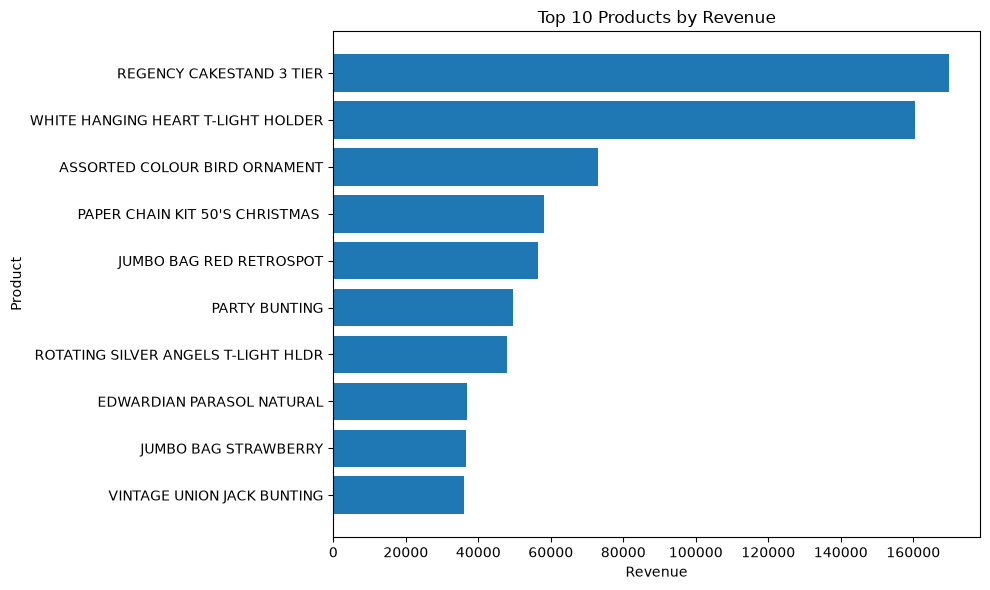

In [14]:
## Top 10 products by revenue
import matplotlib.pyplot as plt
top_products_rev = (
    product_sales
    .groupby
        ("Description")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .sort_values()
    
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_rev.index,
    top_products_rev.values
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

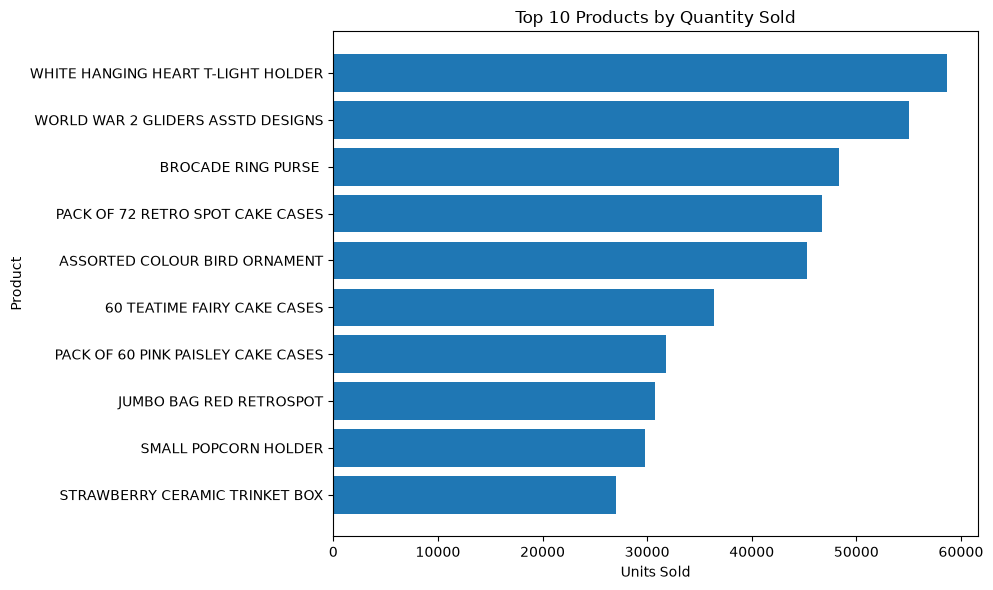

In [15]:
## Top products by quantity

top_products_quantity = (
    product_sales.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_quantity.index,
    top_products_quantity.values
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()